# DAY2 — 고정 Linear Regression 오류 진단

이 노트북은 저장된 개발 OOF·Hold-out·Batch 2 예측 결과를 해석한다. 모델을 학습해 바꾸거나 Batch 2 점수로 설정을 고르지 않는다.

OOF는 각 셀이 빠진 fold에서 나온 예측이다. signed error는 예측−실제이며 양수는 과대 예측을 뜻한다.

In [1]:
from pathlib import Path
import sys
ROOT=next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/day2_dataset.py').is_file())
sys.path.insert(0,str(ROOT))
import pandas as pd
from IPython.display import display,Image
from src.day2_model_diagnostics import load_predictions,summarize,protocol_summary,leave_one_out_slope_influence,save_figures
pred=load_predictions()
train=pd.read_parquet(ROOT/'data/processed/day2/train_batch1.parquet')
train=train.loc[train.partition.isin(['development','holdout'])]
save_figures(pred,train)
display(summarize(pred).round(3))
display(pred.groupby('evaluation_set').signed_error_cycles.agg(['min','median','max']))

,evaluation_set,n,mape_pct,mae_cycles,rmse_cycles,mean_signed_error_cycles,overprediction_n,underprediction_n,median_feature,feature_min,feature_max,median_actual_life
0,Batch 1 development OOF,29,8.656,70.419,89.146,-3.521,16,13,-3.778,-4.147,-3.350,757.0
1,Batch 1 holdout,7,9.080,77.558,91.643,-32.543,2,5,-3.813,-4.179,-3.433,870.0
2,Batch 2 test,39,25.606,129.235,153.029,119.930,35,4,-3.487,-4.449,-3.086,472.0


,min,median,max
evaluation_set,,,
Batch 1 development OOF,-174.974093,11.391634,188.010625
Batch 1 holdout,-136.405609,-59.103113,135.688778
Batch 2 test,-118.923482,135.352406,295.284228


## 실제 수명과 예측, 잔차

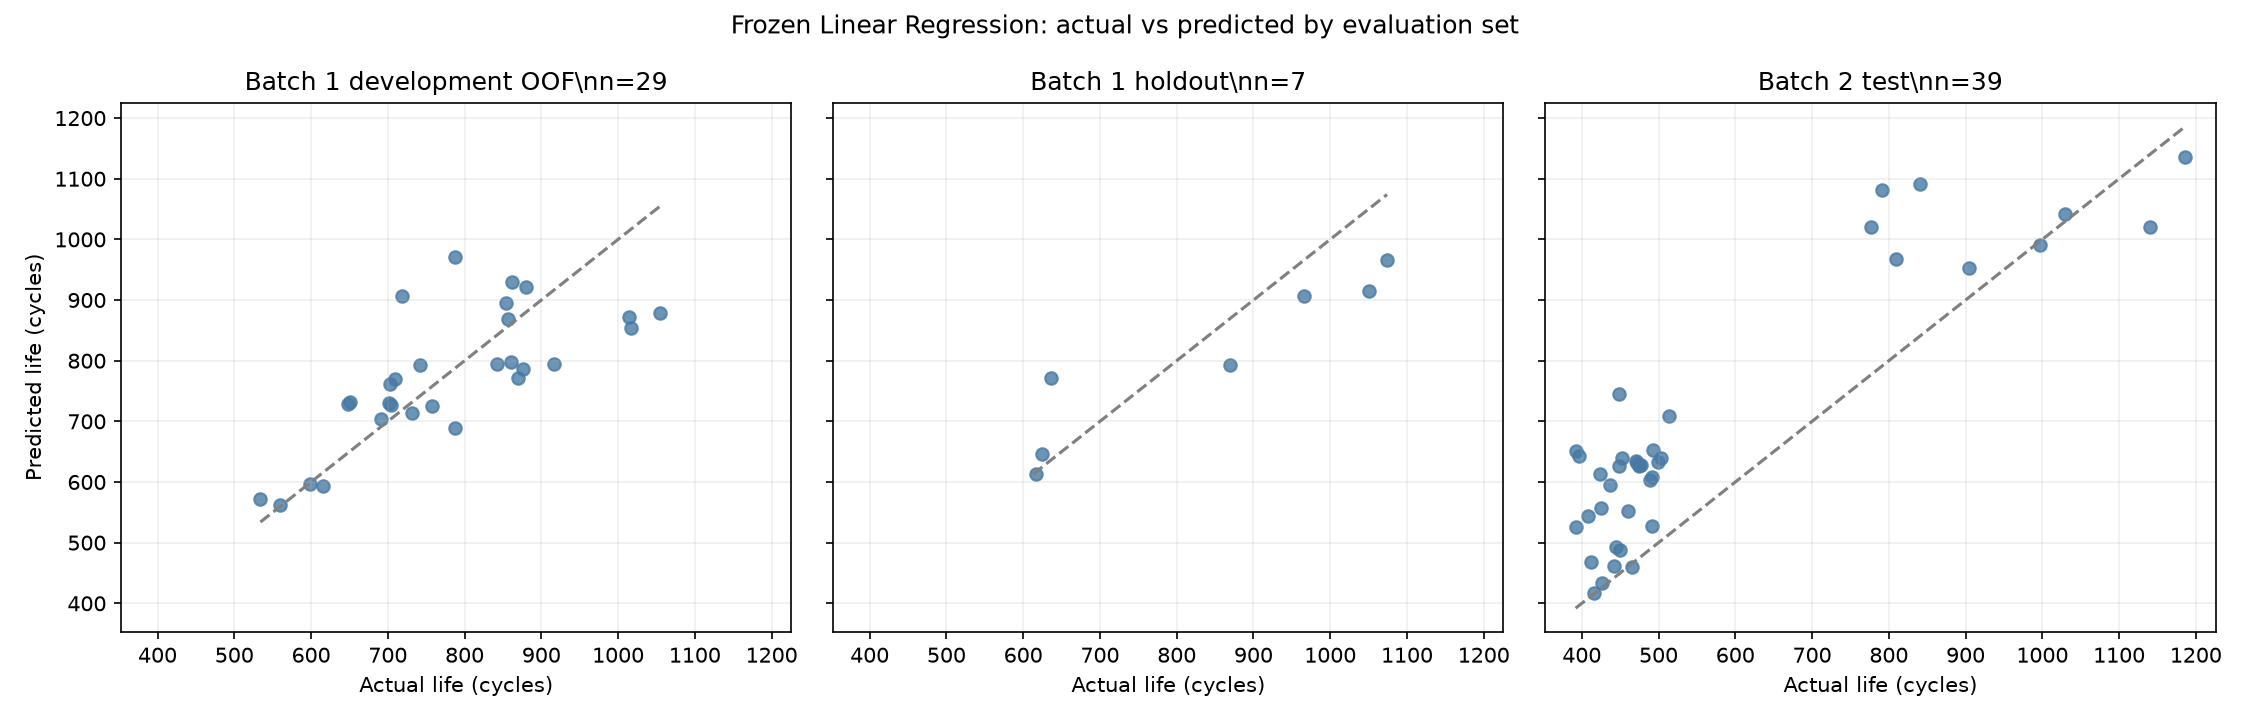

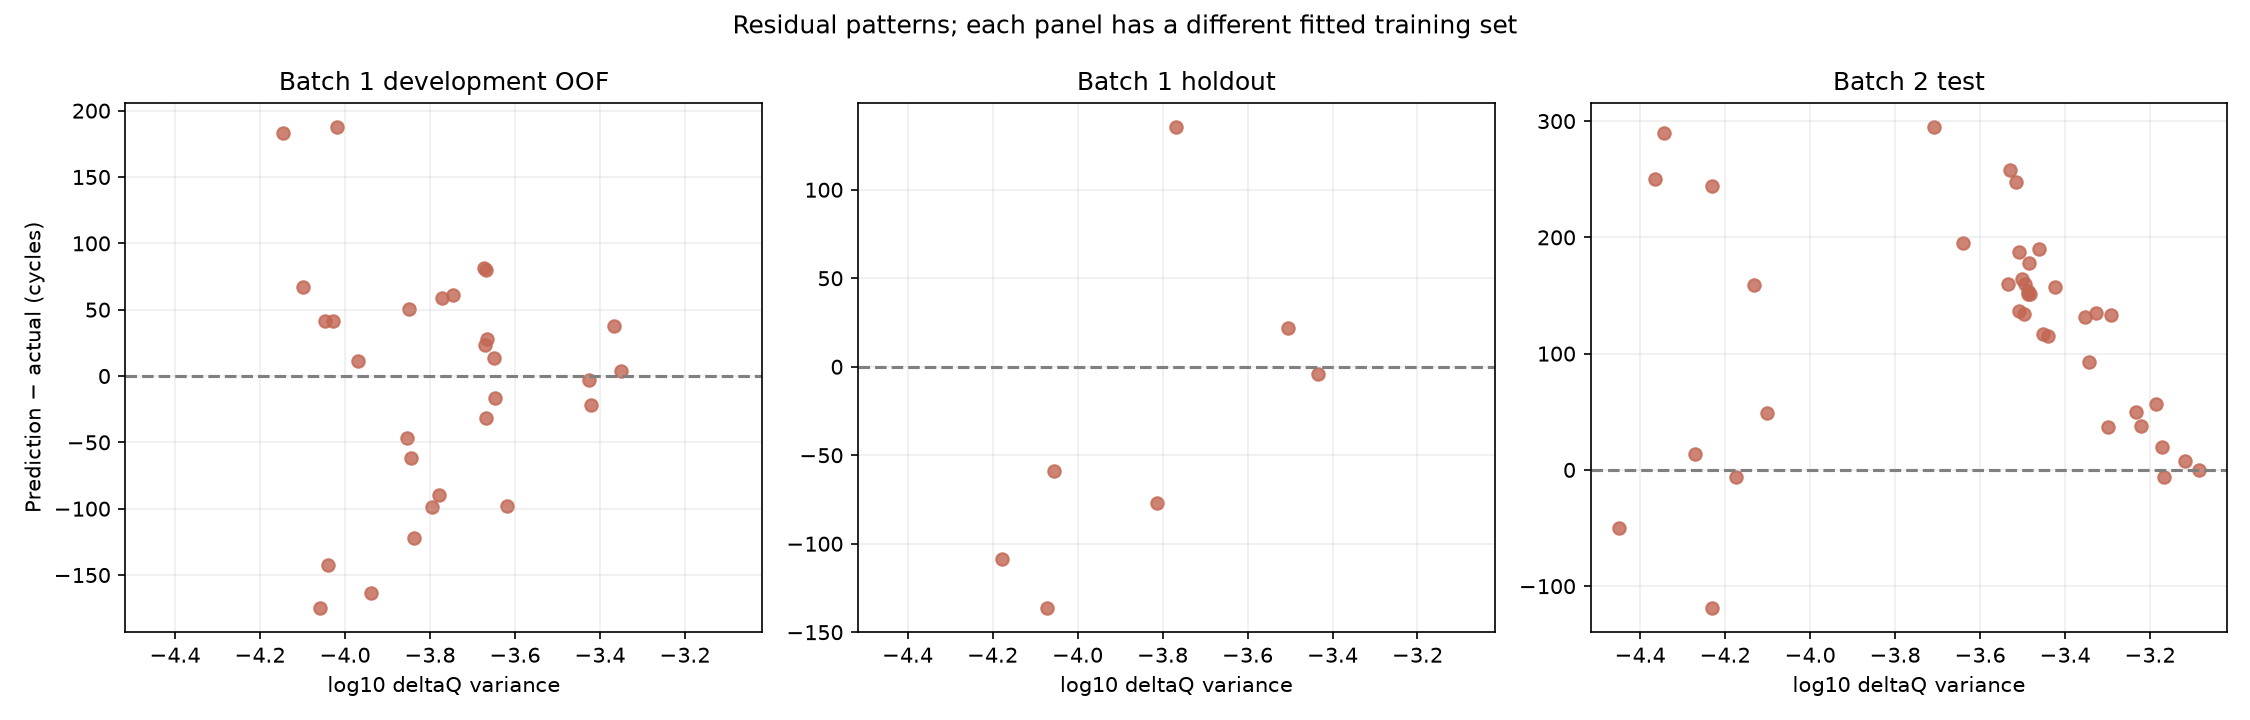

In [2]:
display(Image(filename=str(ROOT/'outputs/figures/day2/model_diagnostics/01_actual_predicted_by_set.png')))
display(Image(filename=str(ROOT/'outputs/figures/day2/model_diagnostics/02_residual_vs_feature.png')))

## 프로토콜별 관찰

프로토콜 그룹마다 셀 수가 작으므로 평균 오차는 설명을 위한 단서로만 읽는다.

In [3]:
protocols=protocol_summary(pred,train)
display(protocols)
shared=set(train.protocol_key)&set(protocols.protocol_key)
print('Batch 1에서 본 프로토콜 그룹:',sorted(shared))
print('Batch 2에서만 나타난 그룹 수:',protocols.seen_in_batch1_train.eq(False).sum())

,protocol_key,n_cells,seen_in_batch1_train,mean_actual_life,mean_predicted_life,mean_signed_error_cycles,mean_ape_pct,max_ape_pct
1,3.6C(9%)-5C,2,False,394.500000,647.067499,252.567499,64.028059,65.574246
6,5.2C(50%)-4.25C,5,False,454.000000,647.701674,193.701674,42.922269,65.764861
11,6C(60%)-3C,2,True,400.000000,534.187752,134.187752,33.554537,33.934464
7,5.2C(58%)-4C,4,False,477.750000,631.060614,153.310614,32.263289,41.416597
4,4.8C(80%)-4.8C,5,True,483.600000,636.849821,153.249821,31.768519,37.981001
5,4.8C(80%)-4.8C-newstructure,3,False,871.666667,1010.524332,138.857665,17.461395,31.415517
9,5.6C(26%)-4.5C,6,False,448.500000,523.160950,74.660950,16.699947,34.825999
3,4.65C(69%)-6C,2,False,452.000000,523.185612,71.185612,15.669566,20.159240
8,5.2C(58%)-4C-newstructure,3,False,961.666667,1021.725718,60.059051,15.197270,29.754112
2,4.65C(44%)-5C,2,False,482.500000,546.217120,63.717120,14.103419,26.826746


Batch 1에서 본 프로토콜 그룹: ['4.8C(80%)-4.8C', '6C(60%)-3C']
Batch 2에서만 나타난 그룹 수: 10


## 한 셀 제외 민감도

Batch 1의 회귀 기울기를 계산한 다음 셀 하나씩 제외해 다시 계산한다. 이 값은 계수 안정성 진단이며 새로운 평가 점수가 아니다.

,cell_id,protocol_key,full_slope_cycles_per_feature_unit,slope_without_cell,slope_change_pct,life,feature
4,11,5.4C(50%)-3C,-527.902,-566.933,-7.394,788.0,-4.147
6,15,5.4C(60%)-3C,-527.902,-551.869,-4.540,719.0,-4.018
3,9,5.4C(40%)-3.6C,-527.902,-509.142,3.554,1054.0,-4.059
0,5,4.4C(80%)-4.4C,-527.902,-509.403,3.504,1074.0,-4.179
31,41,8C(15%)-3.6C,-527.902,-509.715,3.445,1051.0,-4.072
7,16,5.4C(60%)-3.6C,-527.902,-543.646,-2.983,862.0,-4.099
13,23,6C(30%)-3.6C,-527.902,-514.768,2.488,1014.0,-4.041
14,24,6C(40%)-3C,-527.902,-515.695,2.312,1017.0,-3.939
10,19,5.4C(70%)-3C,-527.902,-536.365,-1.603,788.0,-3.620
15,25,6C(40%)-3C,-527.902,-535.789,-1.494,854.0,-4.028


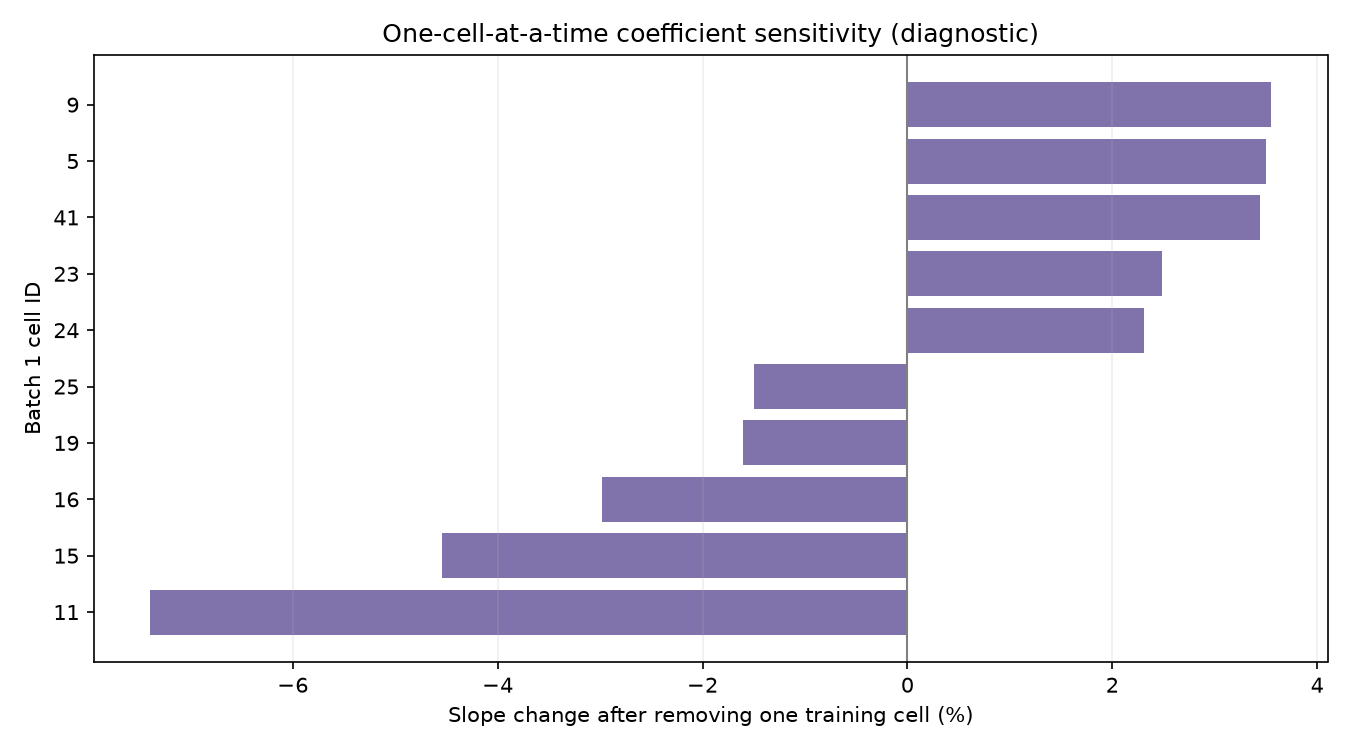

In [4]:
influence=leave_one_out_slope_influence(train)
display(influence.head(10).round(3))
display(Image(filename=str(ROOT/'outputs/figures/day2/model_diagnostics/03_slope_influence.png')))

## 해석

Batch 2에서 과대 예측이 집중되며, 학습 자료에 없는 프로토콜 그룹이 다수다. 동시에 학습에 있던 일부 프로토콜에서도 큰 오차가 나므로 미관측 프로토콜 하나만으로 원인을 설명할 수 없다. 이 진단은 관찰된 동반 패턴을 기록하며 인과관계를 주장하지 않는다.